In [1]:
import numpy as np
import pandas as pd
import sqlite3

np.random.seed(42)

In [2]:
interns = [f'INT{i+1:03d}' for i in range(30)]
months = ['2026-07', '2026-08', '2026-09']

rows = []
for intern in interns:
    base_skill = np.random.normal(0, 1)
    for month in months:
        n_tasks = np.random.randint(4, 10)
        for t in range(n_tasks):
            completion_time = np.clip(np.random.normal(6 - base_skill, 2), 1, 20)
            quality_score = np.clip(np.random.normal(7 + base_skill, 1.2), 1, 10)
            rows.append([intern, month, completion_time, quality_score])

tasks_df = pd.DataFrame(rows, columns=['intern_id', 'month', 'completion_time_hrs', 'quality_score'])

feedback_rows = []
for intern in interns:
    base_skill_fb = np.random.normal(0, 1)
    for month in months:
        feedback = np.clip(np.random.normal(7.5 + base_skill_fb * 0.5, 1.0), 1, 10)
        feedback_rows.append([intern, month, feedback])
feedback_df = pd.DataFrame(feedback_rows, columns=['intern_id', 'month', 'mentor_feedback_score'])

tasks_df.to_csv('task_metrics_raw.csv', index=False)
feedback_df.to_csv('mentor_feedback_raw.csv', index=False)
tasks_df.head()

,intern_id,month,completion_time_hrs,quality_score
0,INT001,2026-07,5.226757,8.065347
1,INT001,2026-07,8.240186,6.396522
2,INT001,2026-07,5.254991,5.083559
3,INT001,2026-07,4.517679,7.967810
4,INT001,2026-07,3.644917,7.592512


In [3]:
conn = sqlite3.connect(':memory:')
tasks_df.to_sql('tasks', conn, index=False, if_exists='replace')
feedback_df.to_sql('feedback', conn, index=False, if_exists='replace')

query = """
SELECT
    t.intern_id,
    t.month,
    COUNT(*) AS tasks_completed,
    ROUND(AVG(t.completion_time_hrs), 2) AS avg_completion_time_hrs,
    ROUND(AVG(t.quality_score), 2) AS avg_quality_score,
    ROUND(AVG(f.mentor_feedback_score), 2) AS avg_mentor_feedback
FROM tasks t
JOIN feedback f ON t.intern_id = f.intern_id AND t.month = f.month
GROUP BY t.intern_id, t.month
"""
kpi_df = pd.read_sql_query(query, conn)
conn.close()
kpi_df.head(10)

,intern_id,month,tasks_completed,avg_completion_time_hrs,avg_quality_score,avg_mentor_feedback
0,INT001,2026-07,6,5.34,7.10,5.83
1,INT001,2026-08,5,6.34,7.11,5.58
2,INT001,2026-09,4,5.74,7.38,7.12
3,INT002,2026-07,5,6.33,6.24,7.45
4,INT002,2026-08,9,6.53,5.62,7.99
5,INT002,2026-09,8,6.97,6.28,6.49
6,INT003,2026-07,8,6.42,6.29,8.65
7,INT003,2026-08,9,5.35,6.33,6.41
8,INT003,2026-09,4,5.96,7.71,7.67
9,INT004,2026-07,7,8.84,4.99,5.98


In [4]:
kpi_df['speed_score'] = (1 - (kpi_df['avg_completion_time_hrs'] / kpi_df['avg_completion_time_hrs'].max())) * 10
kpi_df['performance_score'] = (
    0.3 * kpi_df['speed_score'] +
    0.4 * kpi_df['avg_quality_score'] +
    0.3 * kpi_df['avg_mentor_feedback']
).round(2)

kpi_df.to_csv('intern_kpi_summary.csv', index=False)
kpi_df.sort_values('performance_score', ascending=False).head(10)

,intern_id,month,tasks_completed,avg_completion_time_hrs,avg_quality_score,avg_mentor_feedback,speed_score,performance_score
22,INT008,2026-08,5,2.85,9.09,10.00,6.922246,8.71
73,INT025,2026-08,6,3.63,9.64,8.66,6.079914,8.28
82,INT028,2026-08,5,3.20,9.21,8.31,6.544276,8.14
61,INT021,2026-08,7,4.94,9.35,9.65,4.665227,8.03
74,INT025,2026-09,4,2.95,9.45,7.23,6.814255,7.99
83,INT028,2026-09,9,3.47,8.37,9.07,6.252700,7.94
60,INT021,2026-07,8,3.76,8.81,8.61,5.939525,7.89
51,INT018,2026-07,5,4.26,9.54,8.00,5.399568,7.84
58,INT020,2026-08,7,2.73,7.56,8.15,7.051836,7.58
62,INT021,2026-09,8,4.05,9.38,6.88,5.626350,7.50


In [5]:
for month in months:
    monthly = kpi_df[kpi_df['month'] == month].sort_values('performance_score', ascending=False)
    monthly.to_csv(f'monthly_report_{month}.csv', index=False)
    print(f"=== Report: {month} ===")
    print(f"Top performer: {monthly.iloc[0]['intern_id']} (score {monthly.iloc[0]['performance_score']})")
    print(f"Needs attention: {monthly.iloc[-1]['intern_id']} (score {monthly.iloc[-1]['performance_score']})")
    print(f"Team average: {monthly['performance_score'].mean():.2f}\n")

=== Report: 2026-07 ===
Top performer: INT021 (score 7.89)
Needs attention: INT004 (score 3.93)
Team average: 6.09

=== Report: 2026-08 ===
Top performer: INT008 (score 8.71)
Needs attention: INT004 (score 3.78)
Team average: 6.19

=== Report: 2026-09 ===
Top performer: INT025 (score 7.99)
Needs attention: INT007 (score 3.99)
Team average: 6.19



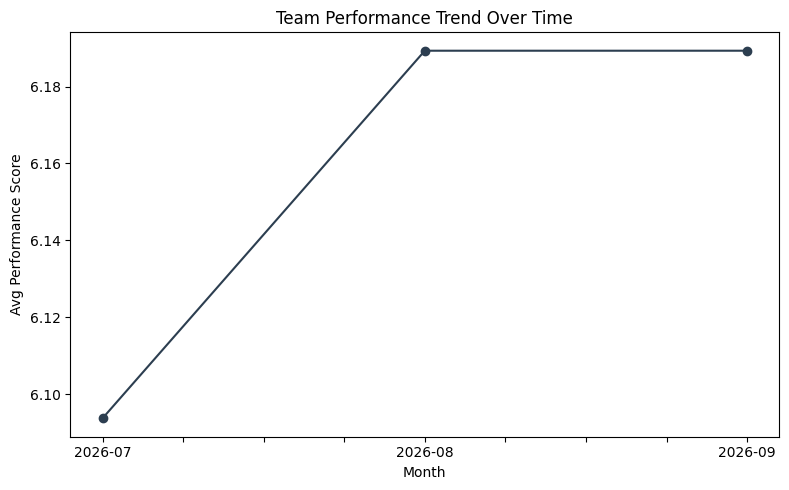

In [6]:
import matplotlib.pyplot as plt

monthly_avg = kpi_df.groupby('month')['performance_score'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
monthly_avg.plot(kind='line', marker='o', color='#2c3e50', ax=ax)
ax.set_ylabel('Avg Performance Score')
ax.set_xlabel('Month')
ax.set_title('Team Performance Trend Over Time')
plt.tight_layout()
plt.savefig('performance_trend.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Team average performance score rose from 6.09 (July) to 6.19 (August/September) and held steady — a positive trend, not just a one-off spike
# INT004 was the lowest performer in both July and August (3.93, then 3.78) — a consistent pattern worth flagging to a mentor for targeted support, rather than a one-off dip
# Top performers shifted month to month (INT021 → INT008 → INT025), suggesting no single intern is carrying the team — performance is fairly distributed
# Recommendation: supervisors should watch for interns who repeat as bottom performers across 2+ months (like INT004) — that's a stronger signal than a single bad month